In [1]:
import pandas as pd
import os
import qa_functions as qa
import utils
import temperature_data_fns as td
import numpy as np
import matplotlib.pyplot as plt
import cleaning_fns as clf
from tqdm import tqdm
import plotly.io as pio
from IPython.display import Image
# xvfb-run executable required when code run in Unix-like systems
conf_xvfb_bool = False if os.name == 'nt' else True
pio.orca.config.use_xvfb = conf_xvfb_bool
pio.orca.config.save()

pd.set_option("display.max_columns", None)

# Define string to be removed/added in the cleaning process. Used for naming outputs:
prefix = "Property_ID="

In [2]:
# Set file format for the raw data you have, either parquet or csv
file_format = qa.set_file_format(file_format="csv")

In [3]:
# Specify which folder contains your local directory
eoh_folder = os.environ["EoH"]

location, location_in_raw, location_out, location_out_cleaned = utils.create_folder_structure(os.path.join(eoh_folder))

# Generate a list of all files to be run through the code
files_info = []

for home in os.listdir(location_in_raw):
    size = os.path.getsize(os.path.join(location_in_raw, home))
    file_info = [home, round(size / 1024)]
    files_info.append(file_info)
# Remove properties which do not have more than 1KB of data
files_info = pd.DataFrame(files_info, columns=["Property_Name", "Size_KB"])
files_info = files_info[files_info["Size_KB"] > 1]
files_list = list(files_info.iloc[:, 0])
files_list = [file.split(".")[0] for file in files_list]

In [4]:
# Define the performance factor ranges for different time scales
# For short time scales, we expect higher variation in the performance factor
# short time periods are around a day, long are around a year, medium is in between these two
spf_ranges = {
    "short": {"min": 0.75, "max": 7.5},
    "medium": {"min": 0.9, "max": 6.5},
    "long": {"min": 1.5, "max": 5.0},
}

In [7]:
# This code is commented out as it takes some time to run
# You can run the code in this cell to generate the temperature_stats.csv
# Alternately if you have already generated the csv then
# you can load the csv in the following cell to view the plots below

all_stats = pd.DataFrame()
for file in tqdm(files_list):
    temperature_data = utils.load_temperature_data(os.path.join(location_in_raw, file), file_format=file_format)
    temperature_data = qa.round_timestamps(temperature_data, n_mins=2)
    path = os.path.join(location_out, "plots", "temperature", file + ".png")
    td.plot_data(temperature_data, path=path)
    temperature_data = temperature_data.reset_index()
    stats = td.get_temperature_stats(temperature_data, file.replace(prefix,""))
    all_stats = pd.concat([all_stats, stats])

path = os.path.join(location_out, "temperature_stats.csv")
all_stats.to_csv(path, index=False)

100%|██████████| 740/740 [8:23:02<00:00, 40.79s/it]      


Homes kept: 713 
Accuracy (train): 97.5% 


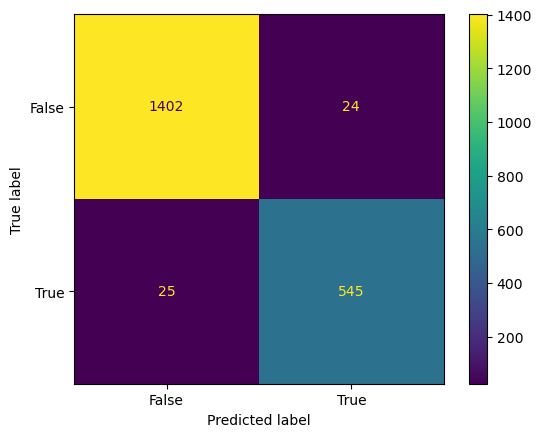

Accuracy (train): 99.4% 


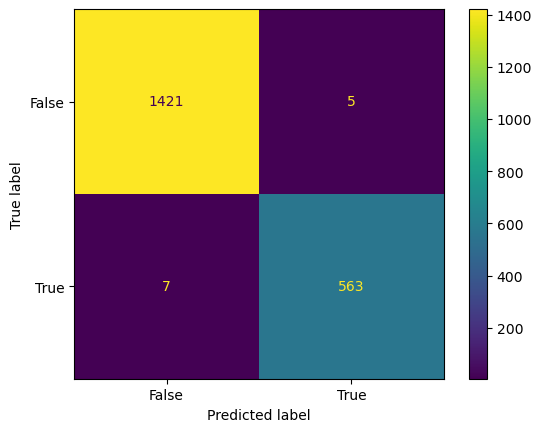

In [8]:
# Using the temperature_stats.csv file, we create classifiers and make predictions
# and create the homes_dropped subset of homes
(
    classifier_A,
    classifier_B,
    predictions_A,
    predictions_B,
    stats_to_use,
    all_stats,
    homes_dropped,
    graph_classififier_A,
    graph_classififier_B,
) = clf.classify_and_predict(location_out, files_list)

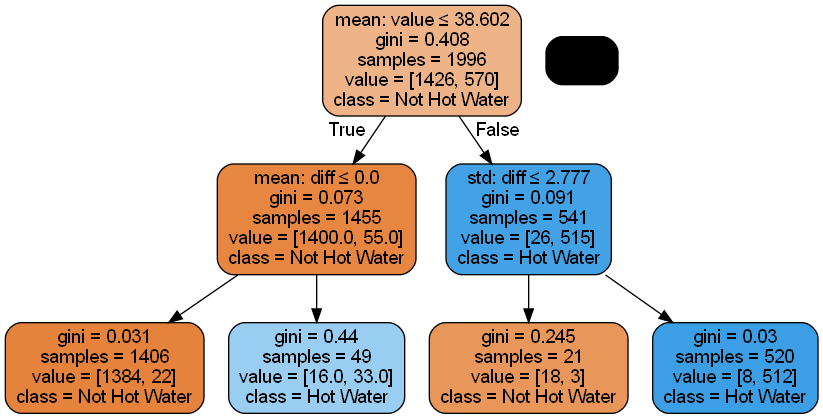

In [9]:
Image(graph_classififier_A.create_png())

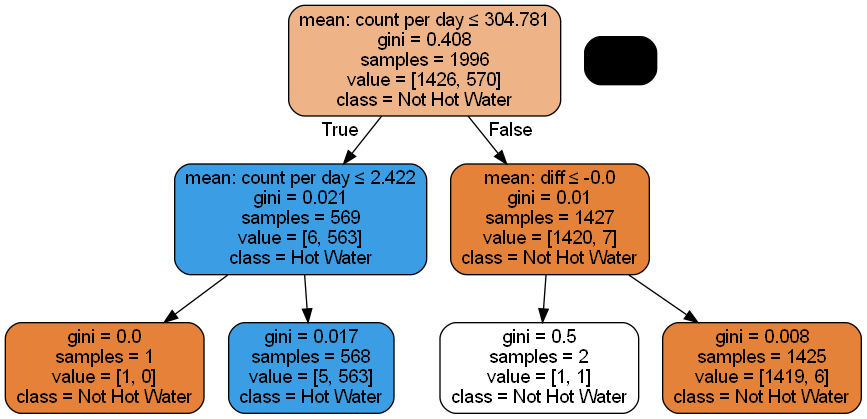

In [10]:
Image(graph_classififier_B.create_png())

In [11]:
# The code in this cell generates 3 more subsets of homes:
# unflagged homes, single_flagged_homes, double_flagged homes

output = stats_to_use.copy()
output["prediction_A"] = predictions_A
output["prediction_B"] = predictions_B
output["flagged_A"] = output["prediction_A"] != (output["sensor_type"] == "Hot_Water_Flow_Temperature")
output["flagged_B"] = output["prediction_B"] != (output["sensor_type"] == "Hot_Water_Flow_Temperature")

# There is a fair difference between how the splits behave, we will have a look at all of them
output["flagged"] = output["flagged_A"] | output["flagged_B"]

home_flags = output.groupby(["Property_ID"])["flagged"].sum()
output = pd.merge(output, home_flags, on="Property_ID", how="left", suffixes=[None, "_per_home"])

# Merge in all_stats to get the issue for the homes dropped for having < 50% temp data
output = pd.merge(
    output,
    all_stats[["sensor_type", "Property_ID", "issue"]],
    on=["sensor_type", "Property_ID"],
    how="outer",
)

flagged_homes = output[output["flagged_per_home"] > 0]
flagged_homes = flagged_homes.groupby("Property_ID").agg({"flagged_per_home": "max"})
unflagged_homes = np.sort(output.loc[output["flagged_per_home"] == 0]["Property_ID"].unique())
single_flagged_homes = flagged_homes.loc[flagged_homes["flagged_per_home"] == 1]
double_flagged_homes = flagged_homes.loc[flagged_homes["flagged_per_home"] == 2]
single_flagged_homes = single_flagged_homes.index.sort_values()
double_flagged_homes = double_flagged_homes.index.sort_values()

  0%|          | 0/678 [00:00<?, ?it/s]c:\Users\irene.garcia\Documents\DS_analysis_tests\review\notebooks\qa_functions.py:87: FutureWarning:

'T' is deprecated and will be removed in a future version, please use 'min' instead.

c:\Users\irene.garcia\Documents\DS_analysis_tests\review\notebooks\data_scoring_fns.py:496: FutureWarning:

Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '3.2' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.

c:\Users\irene.garcia\Documents\DS_analysis_tests\review\notebooks\data_scoring_fns.py:496: FutureWarning:

Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '3.2' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.

c:\Users\irene.garcia\Documents\DS_analysis_tests\review\notebooks\data_scoring_fns.py:579: FutureWarning:

The behavior of DataFrame concaten

,Property_ID,Whole_start,Whole_end,Whole_duration_days,Whole_%_complete_Circulation_Pump_Energy_Consumed,Whole_%_complete_Heat_Pump_Energy_Output,Whole_%_complete_Immersion_Heater_Energy_Consumed,Whole_%_complete_Whole_System_Energy_Consumed,Cleaned_start,Cleaned_end,Cleaned_duration_days,Cleaned_%_complete_Circulation_Pump_Energy_Consumed,Cleaned_%_complete_Heat_Pump_Energy_Output,Cleaned_%_complete_Immersion_Heater_Energy_Consumed,Cleaned_%_complete_Whole_System_Energy_Consumed,Whole_%_complete_Boiler_Energy_Output,Cleaned_%_complete_Boiler_Energy_Output,Whole_%_complete_Back-up_Heater_Energy_Consumed,Cleaned_%_complete_Back-up_Heater_Energy_Consumed
0,EOH0003,2021-04-15 16:16:00,2023-09-28 23:58:00,896.320833,0.968245,0.968256,0.968413,0.968247,2021-04-15 16:18:00,2023-09-28 23:56:00,896.318056,0.968247,0.968256,0.968411,0.968248,NaN,NaN,NaN,NaN
0,EOH0005,2021-05-21 14:00:00,2023-09-28 23:58:00,860.415278,0.994144,0.798839,NaN,0.994144,2021-05-21 14:02:00,2023-09-28 23:56:00,860.412500,0.994145,0.798835,NaN,0.994145,NaN,NaN,NaN,NaN
0,EOH0014,2021-06-22 14:30:00,2022-12-29 16:26:00,555.080556,0.981459,0.981449,NaN,0.981429,2021-08-29 00:00:00,2022-12-29 16:26:00,487.684722,0.978954,0.978940,NaN,0.978931,0.981462,0.901186,NaN,NaN
0,EOH0018,2020-12-19 10:40:00,2023-09-29 00:00:00,1013.555556,0.953923,0.953916,NaN,0.953866,2020-12-19 10:44:00,2023-09-28 23:58:00,1013.551389,0.953924,0.953918,NaN,0.953868,0.953801,0.803903,NaN,NaN
0,EOH0021,2021-08-17 15:30:00,2023-09-28 23:58:00,772.352778,0.952208,0.938699,0.952195,0.952208,2021-08-17 15:32:00,2023-09-28 23:56:00,772.350000,0.952209,0.938692,0.952195,0.952209,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
0,EOH2713,2021-02-26 14:58:00,2022-03-31 23:58:00,398.375000,0.467448,0.467444,0.467423,0.467437,2021-02-26 15:00:00,2022-03-31 23:56:00,398.372222,0.467426,0.467426,0.467406,0.467437,NaN,NaN,NaN,NaN
0,EOH2863,2021-07-13 12:18:00,2021-11-28 12:54:00,138.025000,0.060235,0.059661,NaN,0.060265,2021-07-13 12:18:00,2021-11-28 12:52:00,138.023611,0.060235,0.059642,NaN,0.060255,NaN,NaN,NaN,NaN
0,EOH2938,2021-04-13 14:42:00,2023-09-29 00:00:00,898.387500,0.425818,0.425806,NaN,0.425788,2021-04-13 14:44:00,2023-09-28 23:58:00,898.384722,0.425815,0.425798,NaN,0.425786,0.425818,0.324873,NaN,NaN
0,EOH2991,2021-03-25 14:48:00,2023-09-10 11:58:00,898.881944,0.506486,0.334596,NaN,0.506441,2021-03-25 14:50:00,2023-09-10 11:56:00,898.879167,0.506484,0.334577,NaN,0.506441,0.334621,0.297687,NaN,NaN


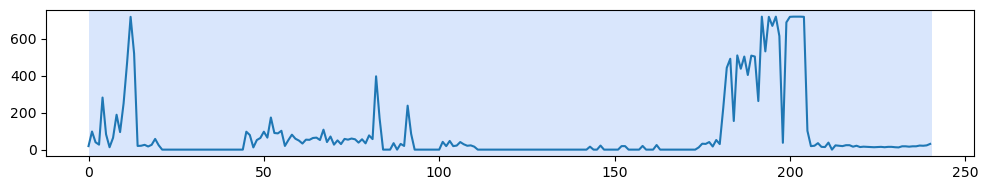

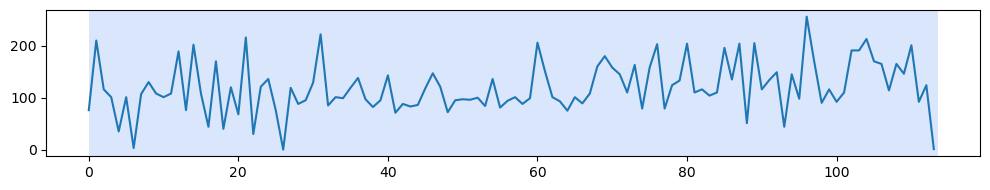

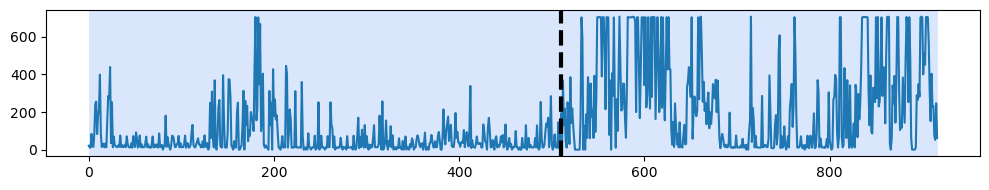

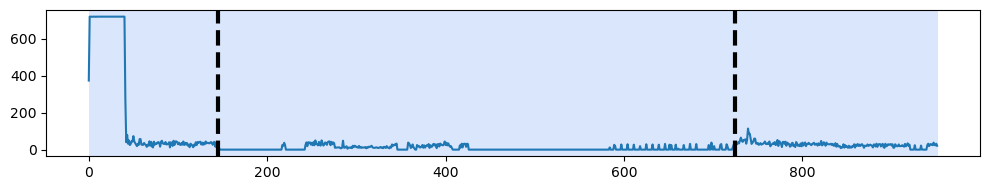

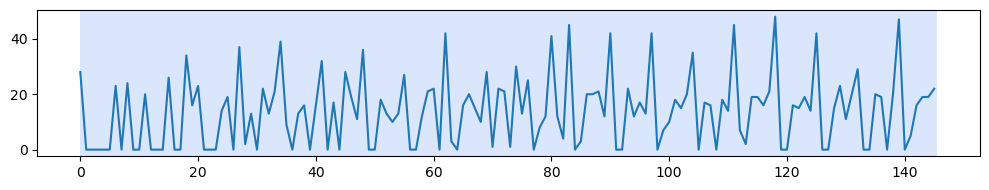

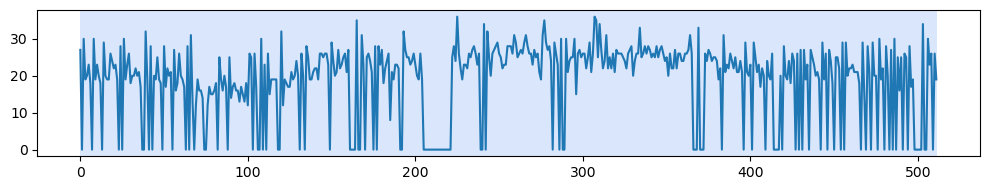

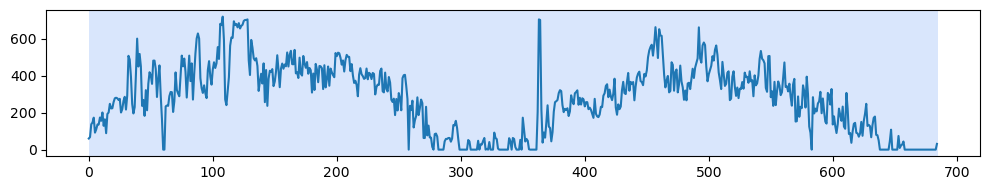

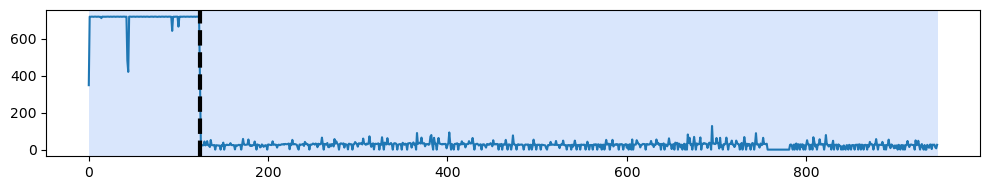

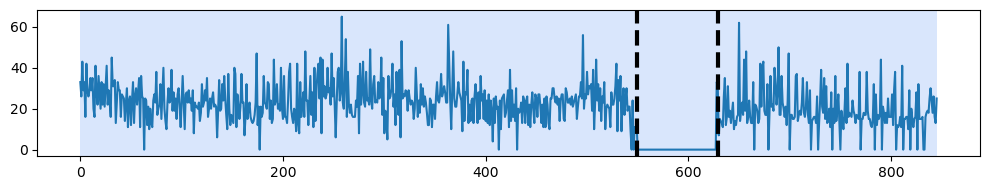

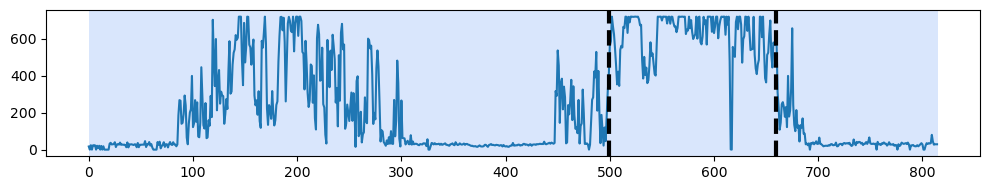

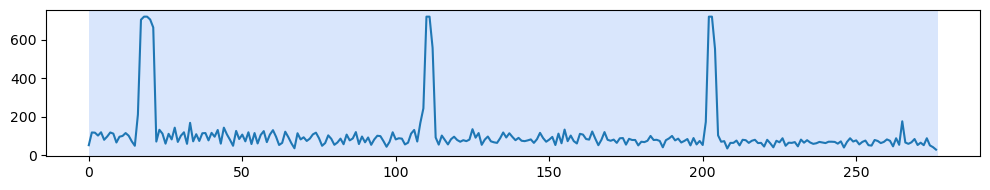

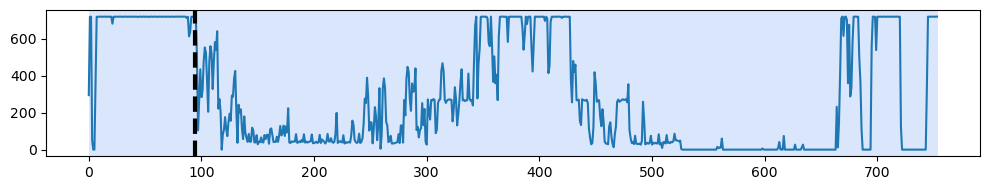

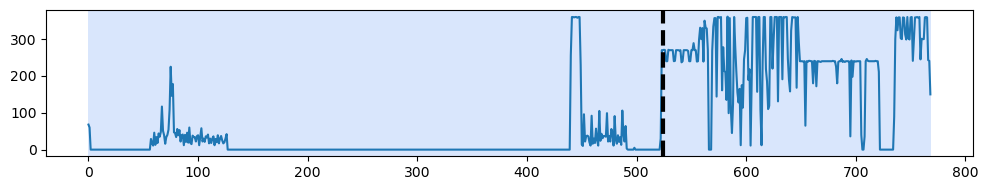

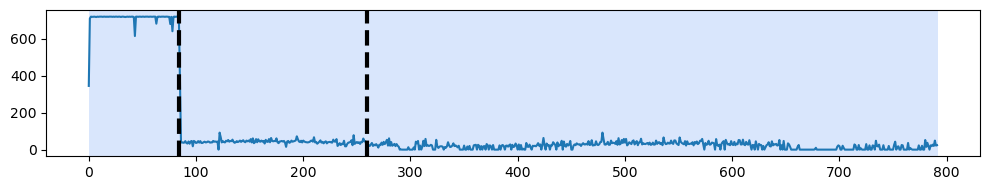

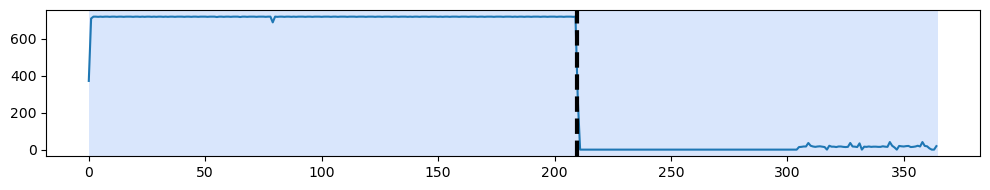

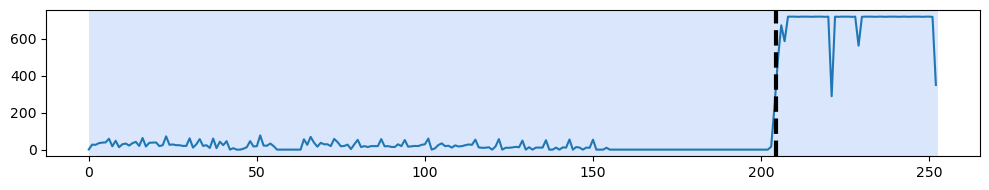

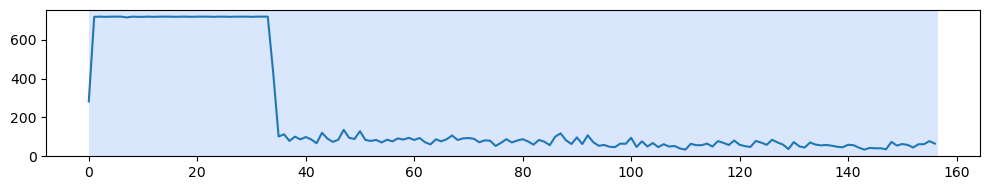

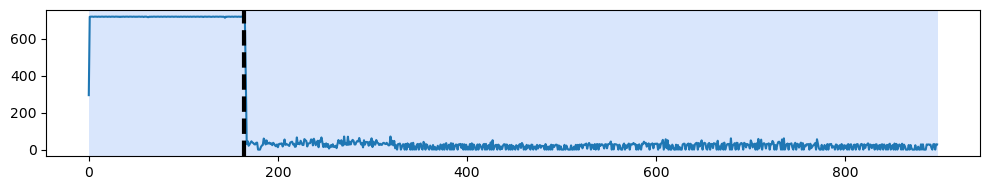

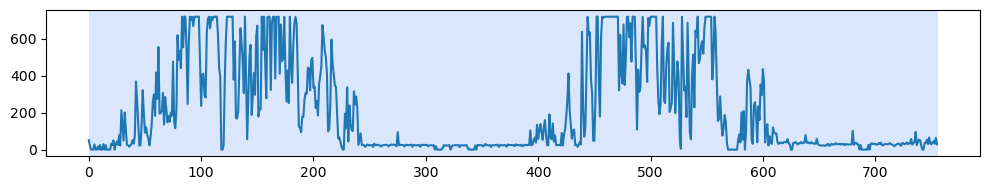

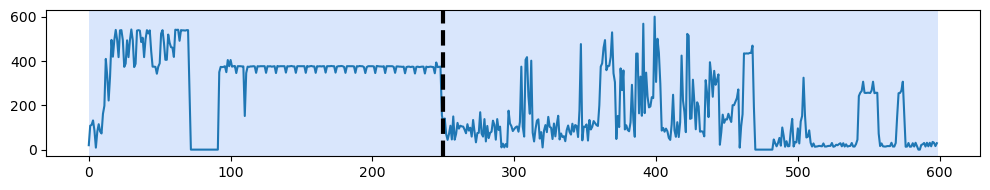

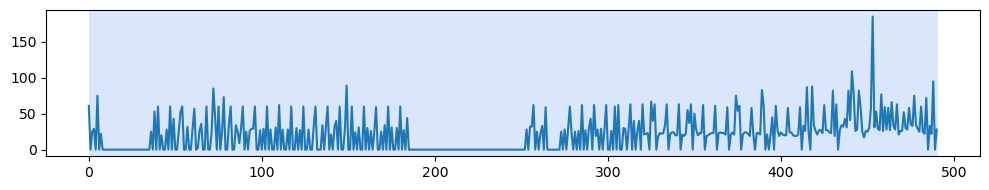

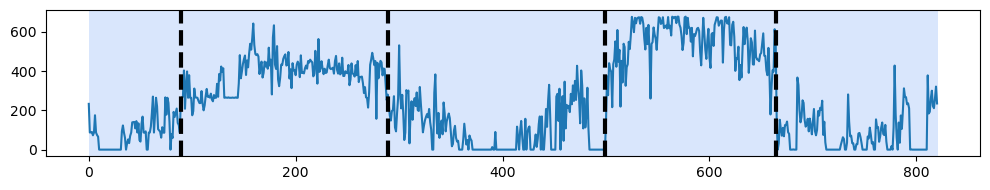

In [10]:
# This cell is where cleaning for each home takes

home_classifications = {
    "unflagged": unflagged_homes,
    "single_flagged": single_flagged_homes,
    "double_flagged": double_flagged_homes,
    "dropped": homes_dropped,
}

# Loop through each home
all_dropped_dupes = 0
window_method = "best"
homes_with_error = []
home_summary = []
all_windows = pd.DataFrame()
all_homes_alteration_record = pd.DataFrame()
alteration_record = pd.DataFrame()

for home_classification in ["unflagged", "single_flagged", "double_flagged", "dropped"]:
    for house_id in tqdm(home_classifications.get(home_classification)):
        
        temp_cleaning_type = home_classification

        home_summary_part, alteration_record, cleaned_data = clf.cleaning(
            house_id,
            location,
            location_in_raw,
            location_out_cleaned,
            spf_ranges,
            all_dropped_dupes,
            alteration_record,
            all_homes_alteration_record,
            temp_cleaning_type,
            output,
            classifier_A,
            classifier_B,
            file_format,
        )

        home_summary.append(home_summary_part)
        all_homes_alteration_record = pd.concat([all_homes_alteration_record, alteration_record])

home_summary = pd.concat(home_summary)
home_summary

In [11]:
# Save the outcomes output
output = output.sort_values("Property_ID")
output.to_csv(os.path.join(location_out, "temperature_stats_with_outcome.csv"))

In [12]:
# Save home summary
home_summary.to_csv(os.path.join(location_out, "home_summary_partial_1.csv"), index=False)

In [13]:
print(f"Total dropped duplicates: {all_dropped_dupes}")

# Save out the alteration record for all the homes
all_homes_alteration_record.to_csv(os.path.join(location_out, "summary_of_alterations.csv"), index=False)

Total dropped duplicates: 0


In [14]:
# Checking as I cannot open the doc:
pathh = os.path.join(location_out, "summary_of_alterations.csv")
dataa = pd.read_csv(pathh)
#
print(dataa.head())
print(all_homes_alteration_record.head())

                        sensor_type           start_time             end_time  \
0  Circulation_Pump_Energy_Consumed  2023-09-28 23:58:00  2023-09-28 23:58:00   
1           Heat_Pump_Energy_Output  2021-04-15 16:16:00  2023-09-28 23:58:00   
2  Immersion_Heater_Energy_Consumed  2021-04-15 16:16:00  2023-09-28 23:58:00   
3      Whole_System_Energy_Consumed  2021-04-15 16:16:00  2021-04-15 16:16:00   
4  Circulation_Pump_Energy_Consumed  2022-04-28 00:02:00  2022-06-08 08:14:00   

                                          alteration                 reason  \
0                            1 data point(s) removed     Anomalous point(s)   
1                            2 data point(s) removed     Anomalous point(s)   
2                            3 data point(s) removed     Anomalous point(s)   
3                            1 data point(s) removed     Anomalous point(s)   
4  max:-5.684341886080802e-14 - min:-1.1368683772...  Drops not reset stats   

  Property_ID  
0     EOH0003  
1     